In [2]:
# Import libraries for path handling and data analysis

from pathlib import Path
import polars as pl

In [3]:
PROJECT_ROOT = Path.cwd().parents[1]

DATA_ROOT = PROJECT_ROOT / "tennis_data"

data_path = DATA_ROOT / "Data"

In [5]:
# Load processed datasets required for calculating player wins

event = pl.read_parquet(data_path / "event.parquet")

home_team = pl.read_parquet(data_path / "home_team.parquet")

away_team = pl.read_parquet(data_path / "away_team.parquet")

event.head()

match_id,first_to_serve,home_team_seed,away_team_seed,custom_id,winner_code,default_period_count,start_datetime,match_slug,final_result_only,snapshot_date,match_datetime
i64,i64,str,str,str,i64,i64,i64,str,bool,date,datetime[μs]
12011306,2,"""8""",null,"""RygsiDdc""",null,3,1706702700,"""passaro-marchenko""",false,2024-02-01,2024-01-31 12:05:00
12017464,1,"""Q""",null,"""iBJcsdQYc""",2,3,1706702700,"""kuhl-salkova""",false,2024-02-01,2024-01-31 12:05:00
12018812,null,"""Q""","""2""","""KMzbsLzjd""",2,3,1706702700,"""gokpinar-hardt""",false,2024-02-01,2024-01-31 12:05:00
12021601,1,"""LL""",null,"""RygsfTx""",1,3,1706702700,"""jorda-sanchis-marchenko""",false,2024-02-01,2024-01-31 12:05:00
12017522,2,"""WC""",null,"""ArQsedIb""",1,3,1706703300,"""tubello-serban""",false,2024-02-01,2024-01-31 12:15:00


In [6]:
# Keep the latest snapshot of each match in the event dataset

event_final = (
    event
    .sort(["match_id", "snapshot_date"])
    .group_by("match_id", maintain_order=True)
    .last()
)

print("Original event rows:", event.height)
print("Final event rows:", event_final.height)
print("Unique matches:", event_final["match_id"].n_unique())

Original event rows: 35053
Final event rows: 16873
Unique matches: 16873


In [7]:
# Keep the latest snapshot of each match for home and away teams

home_team_final = (
    home_team
    .sort(["match_id", "snapshot_date"])
    .group_by("match_id", maintain_order=True)
    .last()
)

away_team_final = (
    away_team
    .sort(["match_id", "snapshot_date"])
    .group_by("match_id", maintain_order=True)
    .last()
)

print("Home team rows:", home_team_final.height)
print("Away team rows:", away_team_final.height)

print("Home unique matches:", home_team_final["match_id"].n_unique())
print("Away unique matches:", away_team_final["match_id"].n_unique())

Home team rows: 12389
Away team rows: 11690
Home unique matches: 12389
Away unique matches: 11690


In [8]:
# Remove snapshot_date because it is not needed for final match-level analysis

event_final = event_final.drop("snapshot_date")
home_team_final = home_team_final.drop("snapshot_date")
away_team_final = away_team_final.drop("snapshot_date")

In [9]:
# Merge event data with home and away team information

matches = (
    event_final
    .join(home_team_final, on="match_id", how="left")
    .join(away_team_final, on="match_id", how="left")
)

matches.head()

match_id,first_to_serve,home_team_seed,away_team_seed,custom_id,winner_code,default_period_count,start_datetime,match_slug,final_result_only,match_datetime,name,slug,gender,user_count,residence,birthplace,height,weight,plays,turned_pro,current_prize,total_prize,player_id,current_rank,name_code,country,full_name,name_right,slug_right,gender_right,user_count_right,residence_right,birthplace_right,height_right,weight_right,plays_right,turned_pro_right,current_prize_right,total_prize_right,player_id_right,current_rank_right,name_code_right,country_right,full_name_right
i64,i64,str,str,str,i64,i64,i64,str,bool,datetime[μs],str,str,str,i64,str,str,f64,i64,str,i64,i64,i64,i64,i64,str,str,str,str,str,str,i64,str,str,f64,i64,str,i64,i64,i64,i64,i64,str,str,str
11974049,null,null,null,"""RNfskjg""",2,3,1707051600,"""belgium-croatia""",false,2024-02-04 13:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
11974052,null,null,null,"""DQfsujp""",2,3,1706882400,"""serbia-slovakia""",false,2024-02-02 14:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
11974053,null,null,null,"""NNfsQTf""",1,3,1706878800,"""switzerland-netherlands""",false,2024-02-02 13:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
11974065,null,null,null,"""PNfsFFg""",1,3,1707055200,"""israel-czech-republic""",false,2024-02-04 14:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
11974066,null,null,null,"""hTfsrpg""",2,3,1706871600,"""ukraine-usa""",false,2024-02-02 11:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


In [10]:
# Check final merged dataset structure

matches.shape, matches.columns

((16873, 45),
 ['match_id',
  'first_to_serve',
  'home_team_seed',
  'away_team_seed',
  'custom_id',
  'winner_code',
  'default_period_count',
  'start_datetime',
  'match_slug',
  'final_result_only',
  'match_datetime',
  'name',
  'slug',
  'gender',
  'user_count',
  'residence',
  'birthplace',
  'height',
  'weight',
  'plays',
  'turned_pro',
  'current_prize',
  'total_prize',
  'player_id',
  'current_rank',
  'name_code',
  'country',
  'full_name',
  'name_right',
  'slug_right',
  'gender_right',
  'user_count_right',
  'residence_right',
  'birthplace_right',
  'height_right',
  'weight_right',
  'plays_right',
  'turned_pro_right',
  'current_prize_right',
  'total_prize_right',
  'player_id_right',
  'current_rank_right',
  'name_code_right',
  'country_right',
  'full_name_right'])

In [11]:
# Display player-related columns

[c for c in matches.columns if "player" in c.lower()]

['player_id', 'player_id_right']

In [12]:
# Check winner_code mapping with player positions

matches.select([
    "match_id",
    "winner_code",
    "player_id",
    "player_id_right"
]).filter(
    pl.col("winner_code").is_not_null()
).head(20)

match_id,winner_code,player_id,player_id_right
i64,i64,i64,i64
11974049,2,null,null
11974052,2,null,null
11974053,1,null,null
11974065,1,null,null
11974066,2,null,null
…,…,…,…
11998448,1,131442,88992
11998449,2,22218,248846
11998450,2,117916,163480


In [13]:
# Check missing values in required columns

matches.select([
    pl.col("winner_code").is_null().sum().alias("null_winner_code"),
    pl.col("player_id").is_null().sum().alias("null_home_player"),
    pl.col("player_id_right").is_null().sum().alias("null_away_player")
])

null_winner_code,null_home_player,null_away_player
u32,u32,u32
607,4484,5183


In [14]:
# Check missing values based on unique matches

matches.group_by("match_id").agg([
    pl.col("winner_code").last().alias("winner_code"),
    pl.col("player_id").last().alias("player_id"),
    pl.col("player_id_right").last().alias("player_id_right")
]).select([
    pl.col("winner_code").is_null().sum().alias("null_winner_matches"),
    pl.col("player_id").is_null().sum().alias("null_home_player_matches"),
    pl.col("player_id_right").is_null().sum().alias("null_away_player_matches")
])

null_winner_matches,null_home_player_matches,null_away_player_matches
u32,u32,u32
607,4484,5183


In [15]:
# Count usable matches for player win analysis

valid_matches = matches.filter(
    (
        (pl.col("winner_code") == 1) &
        (pl.col("player_id").is_not_null())
    )
    |
    (
        (pl.col("winner_code") == 2) &
        (pl.col("player_id_right").is_not_null())
    )
)

valid_matches.select(
    pl.len().alias("valid_matches")
)

valid_matches
u32
13007


In [16]:
# Extract winner player_id based on winner_code

winner_players = valid_matches.with_columns(
    pl.when(pl.col("winner_code") == 1)
    .then(pl.col("player_id"))
    .otherwise(pl.col("player_id_right"))
    .alias("winner_player_id")
)

winner_players.select(
    ["match_id", "winner_code", "player_id", "player_id_right", "winner_player_id"]
).head()

match_id,winner_code,player_id,player_id_right,winner_player_id
i64,i64,i64,i64,i64
11998445,2,287803,192013,192013
11998446,2,62790,273680,273680
11998447,1,64580,77223,64580
11998448,1,131442,88992,131442
11998449,2,22218,248846,248846


In [17]:
# Count total wins for each player

player_wins = (
    winner_players
    .group_by("winner_player_id")
    .agg(
        pl.len().alias("total_wins")
    )
    .sort("total_wins", descending=True)
)

player_wins.head(10)

winner_player_id,total_wins
i64,u32
50901,30
230049,23
231620,23
341818,22
202572,21
152766,21
338890,20
205282,20
82133,20


In [18]:
# Display name-related columns in the merged dataset

[c for c in matches.columns if "name" in c.lower()]

['name',
 'name_code',
 'full_name',
 'name_right',
 'name_code_right',
 'full_name_right']

In [19]:
# Add the winner's full name based on winner_code

winner_players = winner_players.with_columns(
    pl.when(pl.col("winner_code") == 1)
    .then(pl.col("full_name"))
    .otherwise(pl.col("full_name_right"))
    .alias("winner_name")
)

winner_players.select(
    ["match_id", "winner_code", "winner_player_id", "winner_name"]
).head()

match_id,winner_code,winner_player_id,winner_name
i64,i64,i64,str
11998445,2,192013,"""Auger-Aliassime, Felix"""
11998446,2,273680,"""Flavio Cobolli"""
11998447,1,64580,"""Ćorić, Borna"""
11998448,1,131442,"""Mmoh, Michael"""
11998449,2,248846,"""Mayot, Harold"""


In [20]:
# Count wins for each player and display the top 10 players

player_wins = (
    winner_players
    .group_by(["winner_player_id", "winner_name"])
    .agg(
        pl.len().alias("total_wins")
    )
    .sort("total_wins", descending=True)
)

player_wins.head(10)

winner_player_id,winner_name,total_wins
i64,str,u32
50901,"""Popko, Dmitry""",30
231620,"""Chidekh, Clement""",23
230049,"""Jianu, Filip Cristian""",23
341818,"""Faria, Jaime""",22
152766,"""Helgo, Malene""",21
202572,"""Gengel, Marek""",21
205282,"""Kužmová, Katarína""",20
238867,"""Ovcharenko, Oleksandr""",20
338890,"""Merida Aguilar, Daniel""",20


In [21]:
# Check whether each winner player ID is associated with only one name

name_check = (
    winner_players
    .group_by("winner_player_id")
    .agg(
        pl.col("winner_name").n_unique().alias("unique_names")
    )
    .filter(pl.col("unique_names") > 1)
)

name_check

winner_player_id,unique_names
i64,u32
391794,2
82133,2
198197,2


In [22]:
# Display all names associated with player IDs that have multiple names

winner_players.filter(
    pl.col("winner_player_id").is_in([391794, 82133, 198197])
).select(
    ["winner_player_id", "winner_name"]
).unique().sort("winner_player_id")

winner_player_id,winner_name
i64,str
82133,"""Dellien Velasco, Murkel Alejan…"
82133,"""Murkel Dellien"""
198197,"""Arangia, Emiliana"""
198197,"""Arango, Emiliana"""
391794,"""Schiessl, Joao Eduardo"""
391794,"""Schiessl, João Eduardo"""


In [23]:
# Count wins by player ID and assign one representative name to each player

player_wins = (
    winner_players
    .group_by("winner_player_id")
    .agg(
        pl.len().alias("total_wins"),
        pl.col("winner_name").drop_nulls().first().alias("winner_name")
    )
    .sort("total_wins", descending=True)
)

player_wins.head(10)

winner_player_id,total_wins,winner_name
i64,u32,str
50901,30,"""Popko, Dmitry"""
230049,23,"""Jianu, Filip Cristian"""
231620,23,"""Chidekh, Clement"""
341818,22,"""Faria, Jaime"""
202572,21,"""Gengel, Marek"""
152766,21,"""Helgo, Malene"""
338890,20,"""Merida Aguilar, Daniel"""
205282,20,"""Kužmová, Katarína"""
82133,20,"""Dellien Velasco, Murkel Alejan…"


In [24]:
# Calculate the number and percentage of matches used in the win analysis

total_matches = matches.height
valid_match_count = winner_players.height
excluded_matches = total_matches - valid_match_count

print("Total matches:", total_matches)
print("Valid matches:", valid_match_count)
print("Excluded matches:", excluded_matches)
print("Coverage:", round(valid_match_count / total_matches * 100, 2), "%")

Total matches: 16873
Valid matches: 13007
Excluded matches: 3866
Coverage: 77.09 %


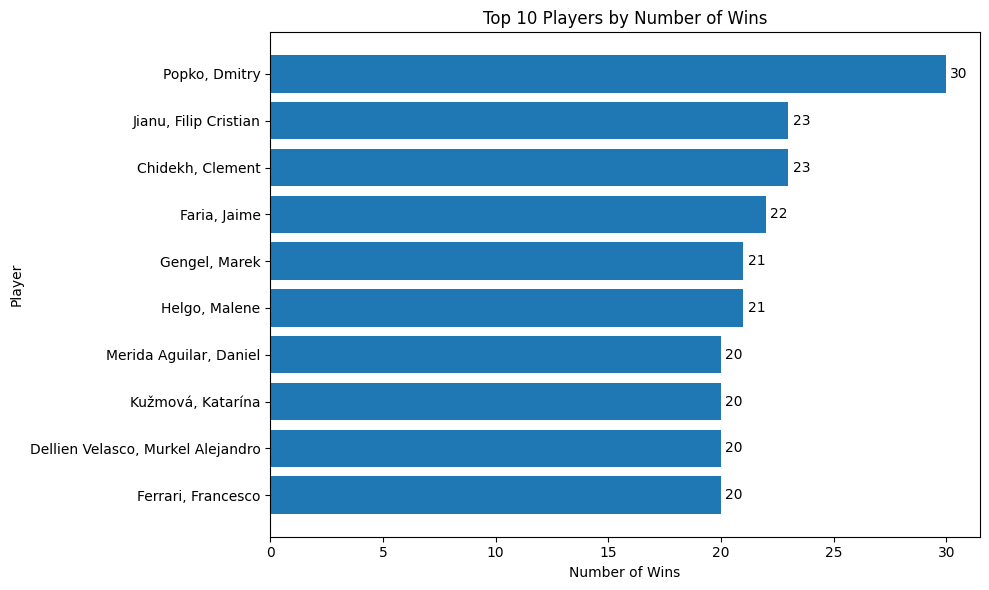

In [25]:
# Visualize the top 10 players with the most wins

import matplotlib.pyplot as plt

top_10 = (
    player_wins
    .head(10)
    .sort("total_wins")
)

names = top_10["winner_name"].to_list()
wins = top_10["total_wins"].to_list()

plt.figure(figsize=(10, 6))

bars = plt.barh(names, wins)

plt.title("Top 10 Players by Number of Wins")
plt.xlabel("Number of Wins")
plt.ylabel("Player")

plt.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()